In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv('../DATA/synthetic_text_data.csv')

In [33]:
df.head()

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology


In [34]:
df.sample(12)

,text,label
26,Cutting-edge technologies are reshaping the la...,Technology
76,Entertainment media is increasingly focusing o...,Entertainment
56,Music fans are eager for live concerts to retu...,Entertainment
63,The political landscape is shifting as new can...,Politics
11,Political leaders are scrambling to address th...,Politics
0,Artificial intelligence is advancing in health...,Technology
44,New technological innovations are enabling bet...,Technology
62,High-tech gadgets are transforming the way we ...,Technology
50,World leaders are discussing international tre...,Politics
8,Music festivals are back this year with global...,Entertainment


In [35]:
df['text'] = df['text'].str.lower()

In [36]:
df.shape

(85, 2)

In [37]:
def remove_num(text):
    out = ''
    for i in text:
        if '0' <= i <= '9':
            out += ' '
        else:
            out += i
    return out

In [38]:
df['text'] = df['text'].apply(remove_num)

In [39]:
df['text']

0     artificial intelligence is advancing in health...
1     football fans are excited about the upcoming w...
2     new policies regarding climate change have spa...
3     the latest blockbuster movie has shattered box...
4     quantum computing promises to revolutionize in...
                            ...                        
80    ai is enhancing customer experiences in retail...
81    politicians are debating the pros and cons of ...
82    television networks are trying to adapt to the...
83    new wearable technologies are improving health...
84    local sports leagues are organizing tournament...
Name: text, Length: 85, dtype: object

In [40]:
X = df['text']
y = df['label']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2 , random_state=42)

In [42]:
from sklearn.feature_extraction.text import CountVectorizer

countvectorizer = CountVectorizer()

In [43]:
X_train_ve = countvectorizer.fit_transform(X_train)
X_test_ve = countvectorizer.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()

In [45]:
model.fit(X_train_ve, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [46]:
y_pred = model.predict(X_test_ve)

In [47]:
y_pred

array(['Politics', 'Technology', 'Technology', 'Politics',
       'Entertainment', 'Entertainment', 'Technology', 'Sports',
       'Technology', 'Politics', 'Politics', 'Technology', 'Sports',
       'Technology', 'Technology', 'Politics', 'Entertainment'],
      dtype='<U13')

In [48]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [49]:
acc_score = accuracy_score(y_pred = y_pred, y_true=y_test)

acc_score

0.8823529411764706

In [50]:
con_mat = confusion_matrix(y_test ,y_pred )

In [51]:
con_mat

array([[2, 0, 0, 0],
       [0, 5, 0, 0],
       [0, 0, 2, 1],
       [1, 0, 0, 6]])

Text(50.722222222222214, 0.5, 'True label')

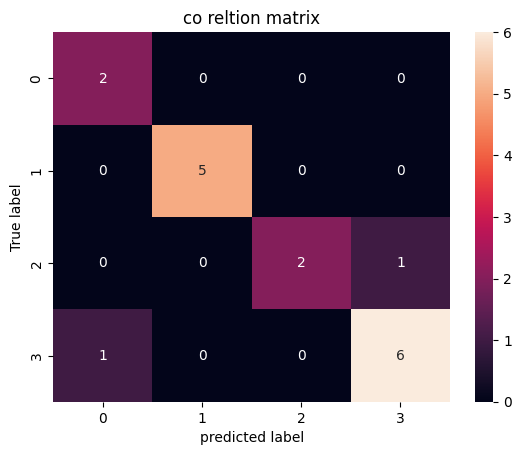

In [52]:
import seaborn as sns
plt.Figure(figsize=(6,5))
sns.heatmap(con_mat, annot=True)
plt.title('co reltion matrix')
plt.xlabel('predicted label')
plt.ylabel('True label')


In [53]:
user_input = ("I love artificial intelligence and machine learning")

user_input_vectorized = countvectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{predicted_label[0]}' category.")


The input text belongs to the 'Technology' category.


In [54]:
import joblib

In [55]:
joblib.dump(model, '../model/my_model.joblib')
joblib.dump(countvectorizer, '../model/vectorizer.joblib')

['../model/vectorizer.joblib']

SVM implementaion

In [56]:
from sklearn.svm import LinearSVC

In [57]:
svm_model = LinearSVC()

In [68]:
from sklearn.metrics import accuracy_score

In [75]:
from sklearn.metrics import accuracy_score

def train_model(model, x_train, y_train, x_test, y_test):

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    
    result = accuracy_score(y_test, y_pred)

    return model, result



In [76]:
model , result = train_model(svm_model, X_train_ve, y_train, X_test_ve, y_test)

In [77]:
result

0.8235294117647058

In [78]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

In [79]:
lr_model , lr_result = train_model(lr_model, X_train_ve, y_train, X_test_ve, y_test)

In [80]:
lr_result

0.8235294117647058